## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [25]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user
# Libraries to help with reading and manipulating data
import scipy.stats as stats
import datetime as datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # To supress warnings
 # set the background for the graphs
from scipy.stats import skew
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import math
import pylab

#AUC ROC curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay #to plot confusion matric
#from sklearn.metrics import plot_confusion_matrix

import statsmodels.api as sm
from scipy import stats
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
# To model the Gaussian Navie Bayes classifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

from sklearn import preprocessing
from scipy.stats import zscore

from sklearn.svm import SVC  # using Gaussian Kernel or Radial Basis Function

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
#AUC ROC curve
from sklearn.tree import DecisionTreeClassifier
# upgrade dependencies

# install zipcode library
!pip install uszipcode sqlalchemy-mate==2.0.0.0
from uszipcode import SearchEngine, SimpleZipcode, ComprehensiveZipcode


**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [26]:
# uncomment and run the following line if using Google Colab
# from google.colab import drive
# Write your code here to read the data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [27]:
# loading data into a pandas dataframe
loan_model = pd.read_csv("/content/drive/My Drive/Loan_Modelling.csv")

## Make a copy of the data set

In [28]:
## Make copy in data
data = loan_model.copy()

## Head the data

In [29]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


##Tail the data

In [30]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


## Check the shape of the data

In [31]:
data.shape
# Print the total number of rows and the columns in the data frame.
print(f'There are {data.shape[0]} rows and {data.shape[1]} columns') # fstring

There are 5000 rows and 14 columns


## Check the data attributes

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [33]:
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

## check the statistical summary

In [34]:
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


## Find any null values

In [35]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [36]:
# we will drop the ID Columns as it does not add a predictibility value
data.drop("ID", axis=1, inplace=True)

In [37]:
data.columns

Index(['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

##Find any missing and unique data

In [38]:
total = data.isnull().sum().sort_values(ascending=False) # Total number of null values
percent = (data.isnull().sum()/data.isnull().count()).sort_values(ascending=False) # Percentage of values that are null
unique =  data.nunique()

missing_unique_data = pd.concat([total, percent, unique], axis=1, keys=['Total', 'Percent','Unique'])
print(missing_unique_data)

                    Total  Percent  Unique
Age                     0      0.0      45
Experience              0      0.0      47
Income                  0      0.0     162
ZIPCode                 0      0.0     467
Family                  0      0.0       4
CCAvg                   0      0.0     108
Education               0      0.0       3
Mortgage                0      0.0     347
Personal_Loan           0      0.0       2
Securities_Account      0      0.0       2
CD_Account              0      0.0       2
Online                  0      0.0       2
CreditCard              0      0.0       2


##Find any duplicate values

In [39]:
# checking for duplicate values
duplidata = data.duplicated()
duplidata.sum()

0

In [40]:
data[duplidata]

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard


##Print all data types

In [41]:
data.dtypes

,0
Age,int64
Experience,int64
Income,int64
ZIPCode,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal_Loan,int64
Securities_Account,int64


In [42]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


##Observations:

1. Age
Evaluation:
The age range (23–67) and average (45 years) appear reasonable for a general dataset involving adults. The distribution being "normal" aligns with expectations for such data.
No issues identified.
2. Experience
Evaluation:
A minimum experience of -3 years is logically inconsistent and indicates potential data entry or calculation errors.
Requires investigation and cleaning.
3. Income
Evaluation:
The income range (USD 46K–224K) with an average of USD 64K and right skewness is expected, as income distributions often exhibit skewness due to high-income outliers.
No major issues but may require transformations for skewness in predictive modeling.
4. Zip Codes
Evaluation:
Treating ZIP codes as integers is inappropriate since they represent locations and do not have numerical significance.
Requires preprocessing (e.g., convert to categorical or one-hot encoding).
5. Family Size
Evaluation:
The family size (1–4) with an average of 2 is reasonable. It being almost uniformly distributed means it could be treated as categorical for modeling.
No issues identified.
6. CCAvg (Credit Card Average Spending)
Evaluation:
The range and average (USD 0K to USD 1.9K; average USD 10K) with right skewness are plausible, as customers without credit cards may have a spending value of 0.
No major issues but may need transformation for skewness.
7. Education
Evaluation:
Properly categorized with labels (1: Undergrad, 2: Graduate, 3: Advanced/Professional). This is well-structured data.
No issues identified.
8. Mortgage
Evaluation:
Mortgage values being highly right skewed (0–USD 635K; average 0) is expected, as many customers may not have a mortgage.
No major issues but consider handling skewness if needed.
9. Categorical Variables (Personal_Loan, Securities_Account, CD_Account, Online, CreditCard)
Evaluation:
These binary variables (0/1) are well-structured and ready for use in analysis or modeling.
No issues identified.
Overall Recommendations:
Investigate and clean Experience data due to the unrealistic negative values.
Address right skewness in Income, CCAvg, Mortgage, Avg_Credit_Limit, and other variables as needed, especially if they are used in regression models or distance-based algorithms.
Treat ZIP Codes as categorical data instead of numerical.
Consider encoding or categorizing variables with significant variances (e.g., Family Size, Education) appropriately for the intended analysis.
Verify any outliers to ensure data quality.


##Sanity checks

In [43]:
# Make a copy of data before treatment
datacopy = data.copy()

# Experience data treatment

In [44]:
# displaying how many rows carries a negative value
print(f'There are {len(data[data["Experience"] < 0])} rows with a negative value')

There are 52 rows with a negative value


In [45]:
negExp = data.Experience < 0
negExp.value_counts()

,count
Experience,
False,4948
True,52


In [46]:
# Checking all the negative values present in the Experience column
data[data['Experience'] < 0]['Experience'].value_counts()

,count
Experience,
-1,33
-2,15
-3,4


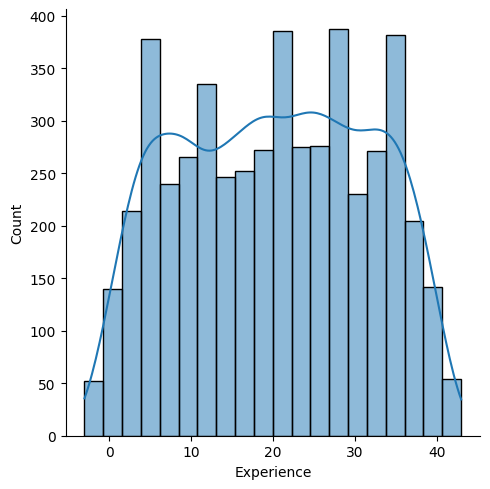

In [47]:
sns.displot(x=data["Experience"], kde=True)

In [48]:
data["Experience"] = data["Experience"].apply(
    lambda x: data["Experience"].median() if x < 0 else x
)

##Check the value counts to confirm successful

In [49]:

len(data[data["Experience"] < 0])

0

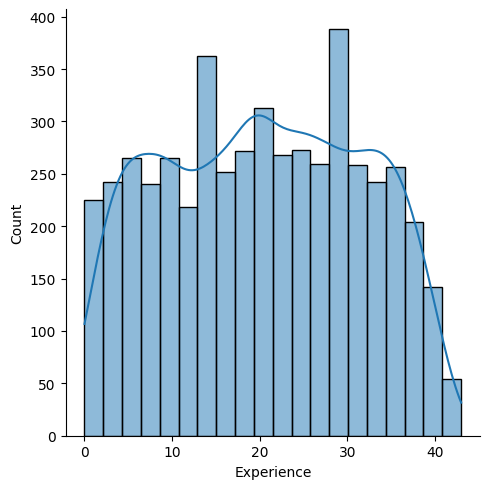

In [50]:
sns.displot(x=data["Experience"], kde=True)

##Zip Code data treatment - convert Zipcode to City State columns

In [24]:
search = SearchEngine()
print(search.by_zipcode("10001"))

Download /root/.uszipcode/simple_db.sqlite from https://github.com/MacHu-GWU/uszipcode-project/releases/download/1.0.1.db/simple_db.sqlite ...
  1.00 MB downloaded ...
  2.00 MB downloaded ...
  3.00 MB downloaded ...
  4.00 MB downloaded ...
  5.00 MB downloaded ...
  6.00 MB downloaded ...
  7.00 MB downloaded ...
  8.00 MB downloaded ...
  9.00 MB downloaded ...
  10.00 MB downloaded ...
  11.00 MB downloaded ...
  Complete!
SimpleZipcode(zipcode='10001', zipcode_type='STANDARD', major_city='New York', post_office_city='New York, NY', common_city_list=['New York'], county='New York County', state='NY', lat=40.75, lng=-74.0, timezone='America/New_York', radius_in_miles=0.9090909090909091, area_code_list='718,917,347,646', population=21102, population_density=33959.0, land_area_in_sqmi=0.62, water_area_in_sqmi=0.0, housing_units=12476, occupied_housing_units=11031, median_home_value=650200, median_household_income=81671, bounds_west=-74.008621, bounds_east=-73.984076, bounds_north=40.

In [ ]:
# function to extract county from the zipcode using searchengine from uszipcode library
def extract_city (zipcode):
    search = SearchEngine(simple_zipcode =  True)
    zip = search.by_zipcode(zipcode)
    return zip.county

# function to extract state from the zipcode using searchengine from uszipcode library
def extract_state (zipcode):
    search = SearchEngine(simple_zipcode =  True)
    zip = search.by_zipcode(zipcode)
    return zip.state

In [ ]:
#create 2 empty lists to fill with city and state for each customer
the_city_ = []
the_state_=[]

#create a for loop to loop on the zipcodes, extract the city and state and fill the lists
for i in np.arange(0,5000):
    try:
        city = extract_city(data["ZIPCode"].iloc[i])
        the_city_.append(city)
        state = extract_state(data["ZIPCode"].iloc[i])
        the_state_.append(state)
    except:
        the_city_.append(np.nan)
        the_state_.append(np.nan)
    continue

In [ ]:
print(the_city_)
print(the_state_)

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

##Convert Categorical data to category type

In [ ]:
# converting categorical variable to category type
category_col = ['Personal_Loan', 'Securities_Account','Family', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode', 'Education']
data[category_col] = data[category_col].astype('category')

In [ ]:
data.groupby(['Age','Education'])['Experience'].describe().T

Age          23               24                               25             \
Education     1     2          1          2          3          1          2   
count       7.0   5.0  13.000000   8.000000   7.000000  23.000000  11.000000   
mean       20.0  20.0   7.692308  15.000000  17.142857   4.173913   7.363636   
std         0.0   0.0  10.127394   9.258201   7.559289   7.432436  10.022702   
min        20.0  20.0   0.000000   0.000000   0.000000   0.000000   0.000000   
25%        20.0  20.0   0.000000  15.000000  20.000000   1.000000   0.000000   
50%        20.0  20.0   0.000000  20.000000  20.000000   1.000000   0.000000   
75%        20.0  20.0  20.000000  20.000000  20.000000   1.000000  20.000000   
max        20.0  20.0  20.000000  20.000000  20.000000  20.000000  20.000000   

Age                          26             ...         64         65  \
Education          3          1          2  ...          3          1   
count      19.000000  30.000000  24.000000  ...  30.000000  30.000000   
mean       10.578947   1.433333   1.625000  ...  38.533333  39.866667   
std        10.205204   0.817200   3.987071  ...   1.756433   0.730297   
min         0.000000   0.000000   0.000000  ...  34.000000  39.000000   
25%         0.000000   1.000000   0.000000  ...  38.000000  39.000000   
50%        20.000000   2.000000   1.000000  ...  39.000000  40.000000   
75%        20.000000   2.000000   1.250000  ...  40.000000  40.000000   
max        20.000000   2.000000  20.000000  ...  40.000000  41.000000   

Age                                     66                               67  \
Education          2          3          1          2          3          1   
count      23.000000  27.000000   9.000000   5.000000  10.000000   5.000000   
mean       40.086957  39.518519  41.111111  41.400000  40.400000  41.600000   
std         0.733178   1.553417   0.333333   0.547723   1.646545   0.894427   
min        39.000000  35.000000  41.000000  41.000000  36.000000  41.000000   
25%        40.000000  39.000000  41.000000  41.000000  40.250000  41.000000   
50%        40.000000  40.000000  41.000000  41.000000  41.000000  41.000000   
75%        41.000000  41.000000  41.000000  42.000000  41.000000  42.000000   
max        41.000000  41.000000  42.000000  42.000000  42.000000  43.000000   

Age                             
Education          2         3  
count       3.000000   4.00000  
mean       42.666667  41.50000  
std         0.577350   0.57735  
min        42.000000  41.00000  
25%        42.500000  41.00000  
50%        43.000000  41.50000  
75%        43.000000  42.00000  
max        43.000000  42.00000  

[8 rows x 134 columns]

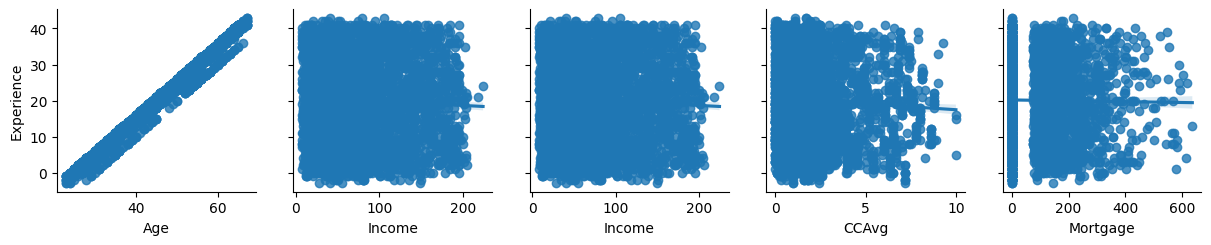

In [ ]:
quantitiveVar = ['Age', 'Income', 'Income', 'CCAvg', 'Mortgage']
expGrid = sns.PairGrid(data, y_vars = 'Experience', x_vars = quantitiveVar)
expGrid.map(sns.regplot)

ValueError: num must be an integer with 1 <= num <= 9, not 10

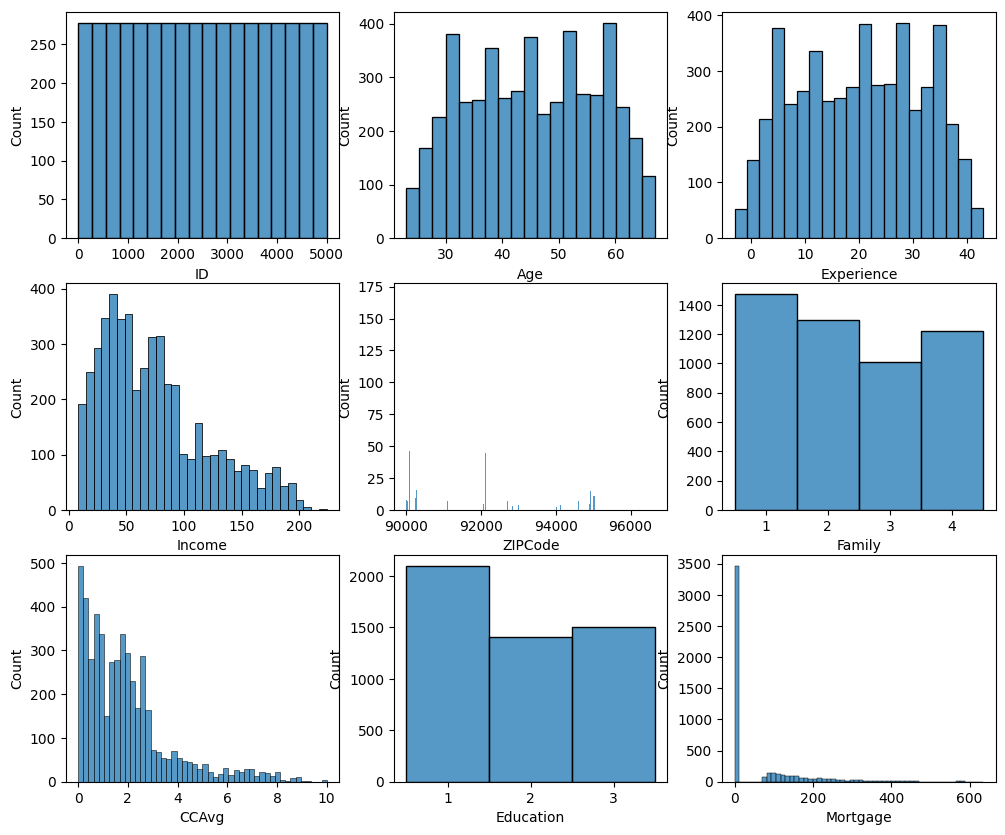

In [ ]:
# defining the figure size
plt.figure(figsize=(12, 10))
# plotting the histogram for each numerical feature
for i, feature in enumerate(data.columns):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

## Model Building

### Model Evaluation Criterion

*


### Model Building

## Model Performance Improvement

## Model Performance Comparison and Final Model Selection

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

___